In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

from matplotlib.colors import LinearSegmentedColormap
import mpl_scatter_density # needed for density scatter plots
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize

# COLORS:
# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#440053"),
    (0.2, "#404388"),
    (0.4, "#2a788e"),
    (0.6, "#21a784"),
    (0.8, "#78d151"),
    (1, "#fde624"),
], N=256)
# "Viridis-like" colormap with white background
white_viridis_r = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#fde624"),
    (0.4, "#78d151"),
    (0.6, "#21a784"),
    (0.7, "#2a788e"),
    (0.8, "#404388"),
    (1, "#440053"),
], N=256)
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

In [3]:
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [4]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [5]:
df = sns.load_dataset('tips')

In [6]:
data["pred"] = np.log2(data["ref"] / data["alt"])
data["pred_procapnet"] = np.log2(data["ref_procapnet_ensemble"] / data["alt_procapnet_ensemble"])
for i in range(7):
    data[f"procapnet_fold_{i}"] = np.log2(data[f"ref_procapnet_fold_{i}"] / data[f"alt_procapnet_fold_{i}"])
data = data[np.isfinite(data["pred"])]
data.dropna(inplace=True)
data = data[data.emVar_K562 == 1]

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
pearsons = [
    pearsonr(data[data["fold"] == fold]["expt"], data[data["fold"] == fold]["pred"])[0]
    for fold in range(10)
]
pearsons_procapnet = pearsonr(data["expt"], data["pred_procapnet"])[0]
pearsons_procapnet_folds = [pearsonr(data["expt"], data[f"procapnet_fold_{i}"])[0] for i in range(7)]
print(pearsons[0], pearsons_procapnet)

pearsons_plot = pd.DataFrame(pearsons + pearsons_procapnet_folds, index=["CLIPNET -> K562"] * 10 + ["ProCapNet K562"] * 7)
pearsons_plot.reset_index(inplace=True)
pearsons_plot.columns = ["Model", "Pearson (expt vs pred emVar)"]

0.5119878596383289 0.3577710063542904


/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

<Axes: xlabel='Model', ylabel='Pearson (expt vs pred emVar)'>

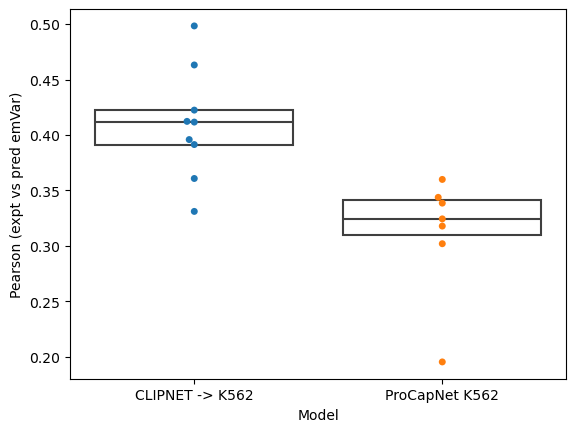

In [8]:
sns.boxplot(
    data=pearsons_plot[1:], x="Model", y="Pearson (expt vs pred emVar)",
    boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, showcaps=False,
)
sns.swarmplot(data=pearsons_plot[1:], x="Model", y="Pearson (expt vs pred emVar)")

In [9]:
mannwhitneyu(pearsons[1:], pearsons_procapnet_folds)

MannwhitneyuResult(statistic=60.0, pvalue=0.0012237762237762239)

In [10]:
signs = [
    (np.sign(data[data.fold == fold].pred) == np.sign(data[data.fold == fold].expt)).mean()
    for fold in range(10)
]
signs_procapnet = (np.sign(data.pred_procapnet) == np.sign(data.expt)).mean()
signs_procapnet_folds = [
    (np.sign(data[f"procapnet_fold_{i}"]) == np.sign(data.expt)).mean()
    for i in range(7)
]

signs_plot = pd.DataFrame(
    signs[1:] + signs_procapnet_folds,
    index=["CLIPNET -> K562"] * 9 + ["ProCapNet K562"] * 7
)
signs_plot.reset_index(inplace=True)
signs_plot.columns = ["Model", "\\% predictions with correct sign"]

<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
/var/folders/sd/3462tpx12fbfxc_f8swcwyf40000gp/T/ipykernel_39668/4210916466.py:5: SyntaxWarning: invalid escape sequence '\%'
  sns.swarmplot(data=signs_plot[1:], x="Model", y="\% predictions with correct sign")
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/seaborn/_core.py:1225: FutureWarning: is_categorical_dtype is deprecated and wi

<Axes: xlabel='Model', ylabel='\\% predictions with correct sign'>

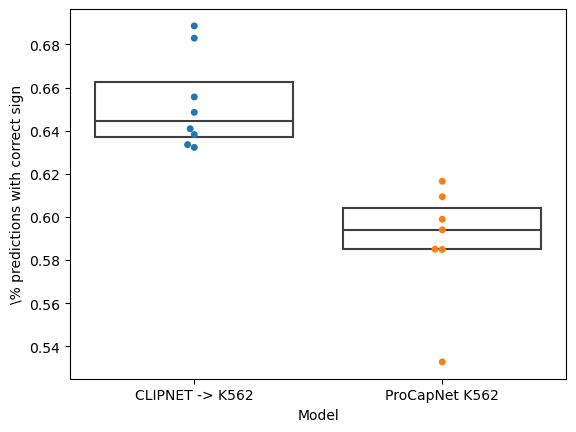

In [11]:
sns.boxplot(
    data=signs_plot[1:], x="Model", y="\\% predictions with correct sign",
    boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':0}, showcaps=False,
)
sns.swarmplot(data=signs_plot[1:], x="Model", y="\% predictions with correct sign")

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


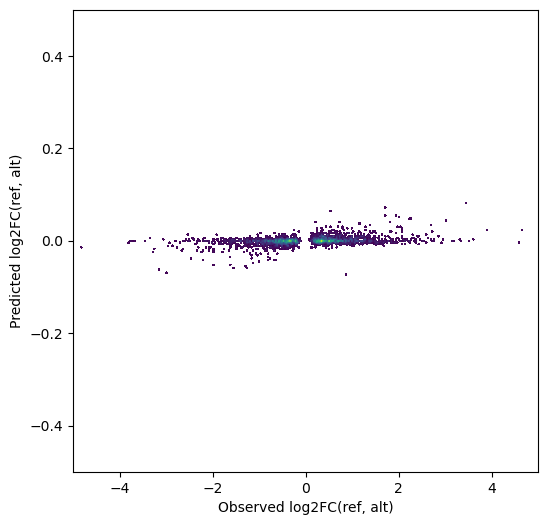

In [12]:
# Plot predicted vs observed log quantities

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection="scatter_density")
density = ax.scatter_density(
    data["expt"][data["fold"] == 0],
    data["pred_procapnet"][data["fold"] == 0],
    cmap=white_viridis
)
#fig.colorbar(density)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 0.5)
#ax.set_yticks([-0, 3])
#ax.set_yticklabels(["", ""])
#ax.set_xticks([-0, 3])
#ax.set_xticklabels(["", ""])
ax.set_ylabel("Predicted log2FC(ref, alt)")
ax.set_xlabel("Observed log2FC(ref, alt)")
plt.savefig("procapnet_ensemble_mpra_predictions.pdf")

#pearsonr(log_sums["pred"], log_sums["expt"])

/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/adamhe/miniforge3/envs/plt/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


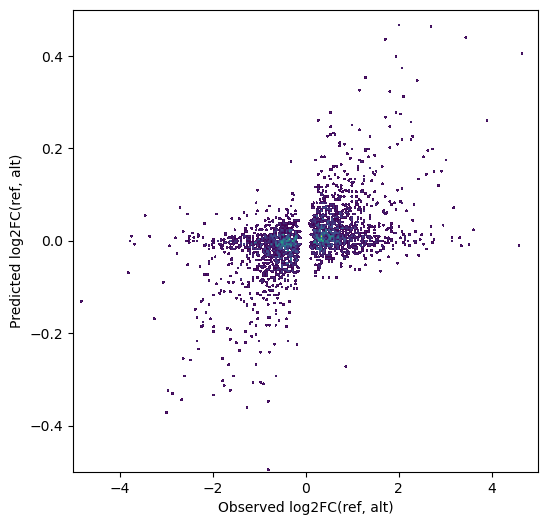

In [13]:
# Plot predicted vs observed log quantities

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection="scatter_density")
density = ax.scatter_density(
    data["expt"][data["fold"] == 0],
    data["pred"][data["fold"] == 0],
    cmap=white_viridis
)
#fig.colorbar(density)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 0.5)
#ax.set_yticks([-0, 3])
#ax.set_yticklabels(["", ""])
#ax.set_xticks([-0, 3])
#ax.set_xticklabels(["", ""])
ax.set_ylabel("Predicted log2FC(ref, alt)")
ax.set_xlabel("Observed log2FC(ref, alt)")
plt.savefig("clipnet_ensemble_mpra_predictions.pdf")

#pearsonr(log_sums["pred"], log_sums["expt"])

In [14]:
signs[0]

0.7085181898846495

In [15]:
pearsons

[0.5119878596383289,
 0.3913978449728768,
 0.42244589484266476,
 0.39589214820843943,
 0.46313046919356504,
 0.3608130351183288,
 0.41229038482543856,
 0.3311444132375651,
 0.4983257516401296,
 0.41166034006903196]

In [16]:
signs_procapnet

0.6103084021369597